# Question 1

dict_keys(['__header__', '__version__', '__globals__', 'IFT_vert', 'IFT_horiz'])


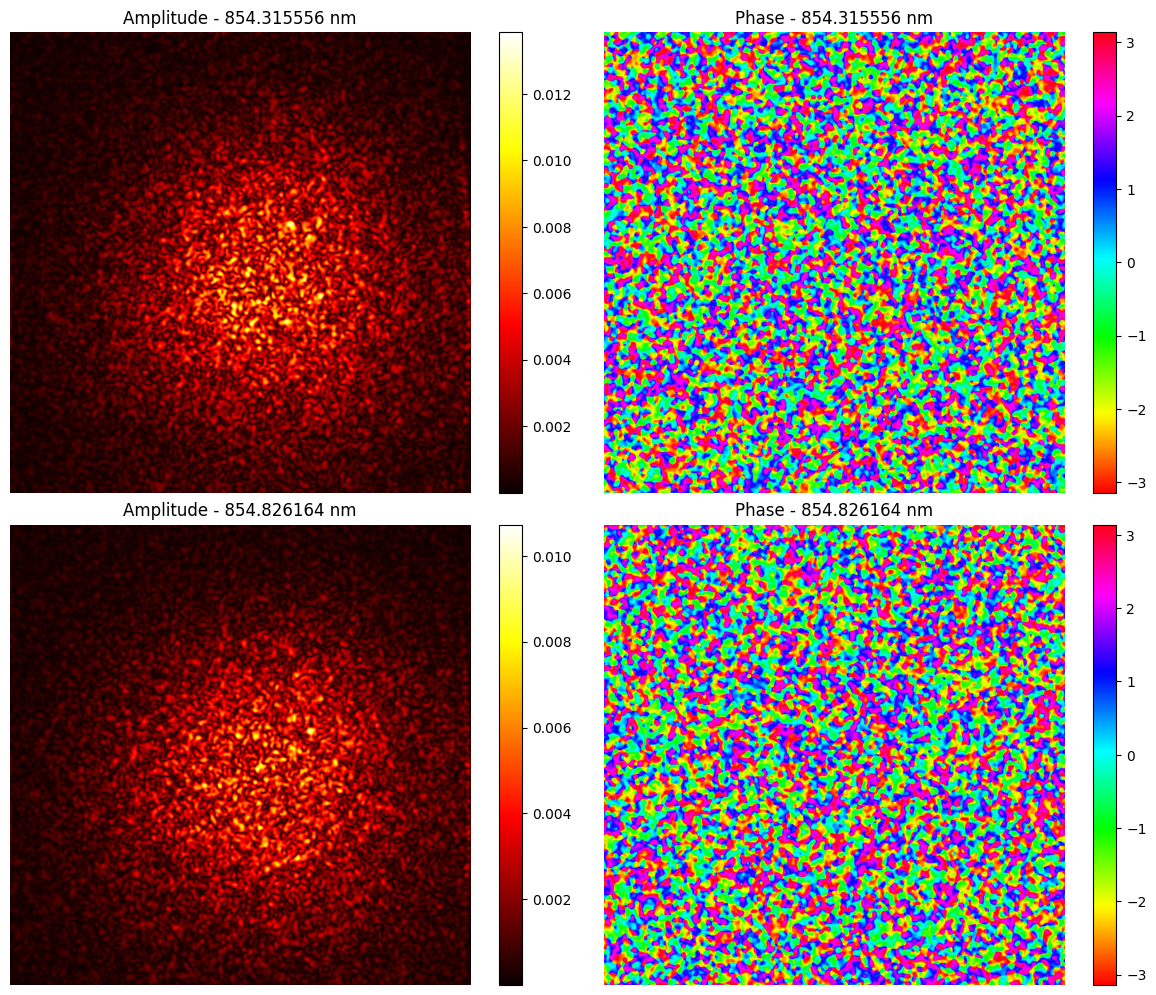

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Load the .mat file (replace with your actual file path)
file_path = 'assignment_4/provided_resource/dataset_part_3.mat'
mat_data = loadmat(file_path)

print(mat_data.keys())
# Assuming the file contains two variables, e.g., 'hologram1' and 'hologram2'
# Adjust these keys based on the actual variable names in your .mat file
hologram1 = mat_data['IFT_vert']  # First wavelength: 854.315556 nm
hologram2 = mat_data['IFT_horiz']  # Second wavelength: 854.826164 nm

# Calculate amplitude (magnitude of the complex field)
amp1 = np.abs(hologram1)
amp2 = np.abs(hologram2)

# Calculate phase (in radians)
phase1 = np.angle(hologram1)
phase2 = np.angle(hologram2)

# Create figure for plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot Amplitude for Wavelength 1
axs[0, 0].imshow(amp1, cmap='hot')
axs[0, 0].set_title('Amplitude - 854.315556 nm')
axs[0, 0].axis('off')
plt.colorbar(axs[0, 0].imshow(amp1, cmap='hot'), ax=axs[0, 0])

# Plot Phase for Wavelength 1
axs[0, 1].imshow(phase1, cmap='viridis')
axs[0, 1].set_title('Phase - 854.315556 nm')
axs[0, 1].axis('off')
plt.colorbar(axs[0, 1].imshow(phase1, cmap='hsv'), ax=axs[0, 1])

# Plot Amplitude for Wavelength 2
axs[1, 0].imshow(amp2, cmap='hot')
axs[1, 0].set_title('Amplitude - 854.826164 nm')
axs[1, 0].axis('off')
plt.colorbar(axs[1, 0].imshow(amp2, cmap='hot'), ax=axs[1, 0])

# Plot Phase for Wavelength 2
axs[1, 1].imshow(phase2, cmap='viridis')
axs[1, 1].set_title('Phase - 854.826164 nm')
axs[1, 1].axis('off')
plt.colorbar(axs[1, 1].imshow(phase2, cmap='hsv'), ax=axs[1, 1])

# Adjust layout and display
plt.tight_layout()
plt.show()

# Question 2

dict_keys(['__header__', '__version__', '__globals__', 'IFT_vert', 'IFT_horiz'])


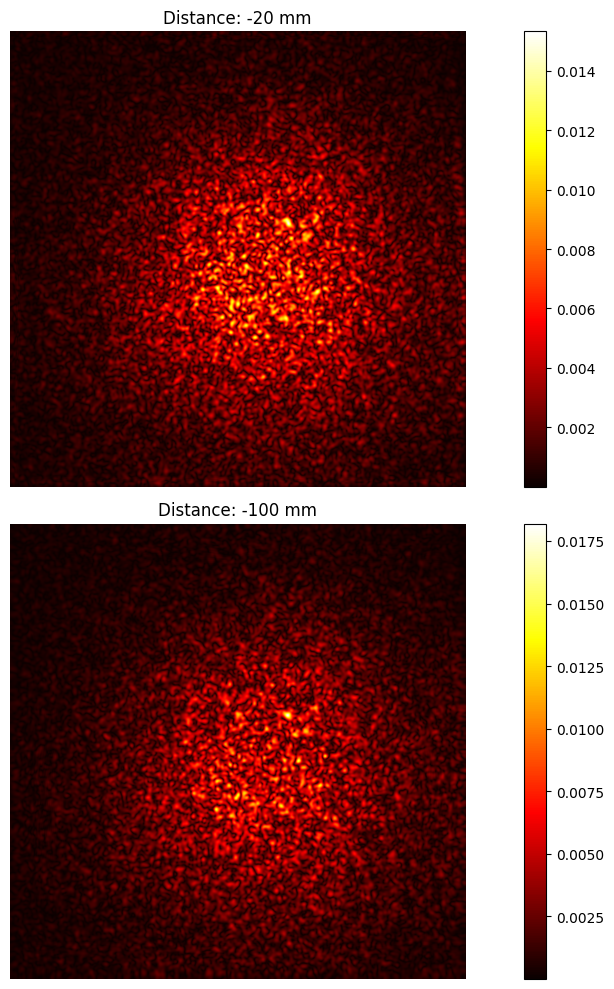

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Load the .mat file (adjust the path as needed)
file_path = 'assignment_4/provided_resource/dataset_part_3.mat'
mat_data = loadmat(file_path)

# Check the keys to identify the hologram variables
print(mat_data.keys())

# Assuming 'hologram1' is the key for 854.315556 nm (adjust as needed)
hologram1 = mat_data['IFT_vert']

# Parameters
wavelength = 854.315556e-6  # Convert nm to mm (854.315556 nm)
dx = dy = 0.01              # Pixel size in mm (assumed, adjust if known)
distances = [-20,-100]  # Propagation distances in mm (negative for back-propagation)

# ASM function (as provided)
def ASM(E_input,wavelength,dx,dy,propagation_distance,freqfilt=False):
    #  INPUT PARAMETERS
    #  E_input = A 2D complex matrix with the initial electric field
    #  wavelength, in mm 
    #  dx, dy = pixel size, in mm
    #  propagation_distance, in mm

    # Adding some padding
    pad = 2000
    E_input = np.pad(E_input, pad)
    [Ny, Nx] = E_input.shape
 
    # Fourier transform of the input E_input
    E_input_fft = np.fft.fft2(E_input)
    
    # Calculate the wave number, k space
    wave_number = 1/wavelength
    
    # Constructing the frequency grid
    kx = np.fft.fftshift(np.arange(-Nx/2,(Nx/2))/Nx/dx)
    ky = np.fft.fftshift(np.arange(-Ny/2,(Ny/2))/Ny/dy)
    [KX, KY] = np.meshgrid(kx, ky)
    # print(np.max(KX),np.max(KY),wave_number**2)


    # Kernel
    if not freqfilt:
        propagation_function = np.exp(1j*2*np.pi*(propagation_distance)*np.sqrt((wave_number**2 - KX**2 - KY**2)))
        propagation_function[np.isnan(propagation_function)] = 0

    else:
        #################################################################
        # Bandlimit the kernel
        # see band-limited ASM - Matsushima et al. (2009)
        # K. Matsushima and T. Shimobaba, 
        # "Band-Limited Angular Spectrum Method for Numerical Simulation of Free-Space Propagation in Far and Near Fields,"
        #  Opt. Express  17, 19662-19673 (2009).
        #################################################################
        K_lambda = 2*np.pi /  wavelength # T x C x H x W
        K_lambda_2 = K_lambda**2
        K2 = KX**2+KY**2
        ang = - propagation_distance * np.sqrt(K_lambda_2 - K2+0j) # T x C x H x W
        if np.iscomplexobj(ang):
            ang = ang.real
        # size of the field
        # # Total field size on the hologram plane
        length_x = Nx* dx 
        length_y = Ny  * dy

        # band-limited ASM - Matsushima et al. (2009)
        f_y_max = 2*np.pi / np.sqrt((2 * propagation_distance * (1 / length_x) ) **2 + 1) / wavelength
        f_x_max = 2*np.pi / np.sqrt((2 * propagation_distance * (1 / length_y) ) **2 + 1) / wavelength


        H_filter = np.zeros_like(ang)
        H_filter[ ( np.abs(KX) < f_x_max) & (np.abs(KY) < f_y_max) ] = 1


        propagation_function =  H_filter * np.exp(1j*H_filter * ang)
    
    #  Applying the filter in the Fourier domain
    E_input_fft_propagated = E_input_fft*propagation_function
    
    #  Inverse Fourier transform to obtain the propagated E_input
    E_input_propagated = np.fft.ifft2(E_input_fft_propagated)

    return E_input_propagated[pad:-pad,pad:-pad]

# Reconstruct and plot
fig, axs = plt.subplots(len(distances), 1, figsize=(12, 10))
axs = axs.ravel()

for i, dist in enumerate(distances):
    # Back-propagate the hologram
    reconstructed_field = ASM(hologram1, wavelength, dx, dy, dist)
    
    # Calculate intensity (amplitude squared)
    intensity = np.abs(reconstructed_field)
    
    # Plot the intensity
    axs[i].imshow(intensity, cmap='hot')
    axs[i].set_title(f'Distance: {dist} mm')
    axs[i].axis('off')
    plt.colorbar(axs[i].imshow(intensity, cmap='hot'), ax=axs[i])

plt.tight_layout()
plt.show()

dict_keys(['__header__', '__version__', '__globals__', 'IFT_vert', 'IFT_horiz'])


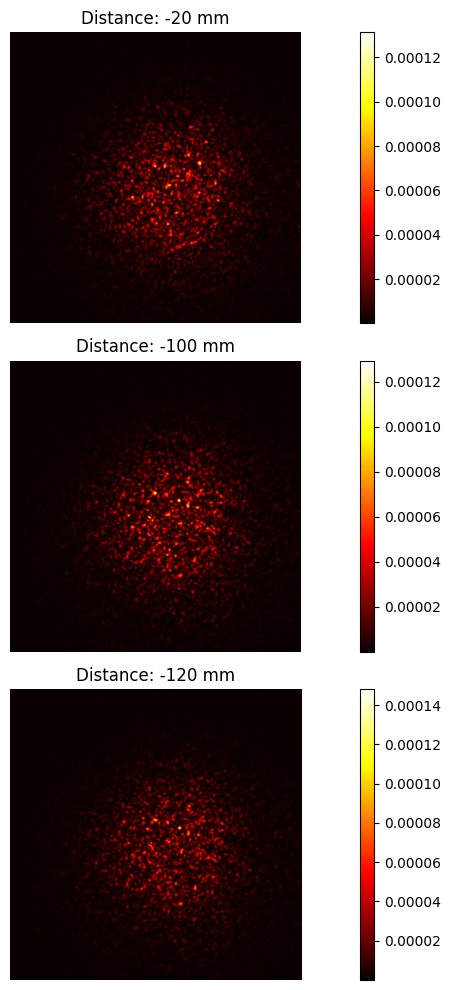

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Load the .mat file (adjust the path as needed)
file_path = 'assignment_4/provided_resource/dataset_part_3.mat'
mat_data = loadmat(file_path)

# Check the keys to identify the hologram variables
print(mat_data.keys())

# Assuming 'hologram1' is the key for 854.315556 nm (adjust as needed)
hologram1 = mat_data['IFT_horiz']

# Parameters
wavelength = 854.826164e-6  # Convert nm to mm (854.826164 nm)
dx = dy = 0.01              # Pixel size in mm (assumed, adjust if known)
distances = [-20,-100, -120]  # Propagation distances in mm (negative for back-propagation)

# ASM function (as provided)
def ASM(E_input,wavelength,dx,dy,propagation_distance,freqfilt=False):
    #  INPUT PARAMETERS
    #  E_input = A 2D complex matrix with the initial electric field
    #  wavelength, in mm 
    #  dx, dy = pixel size, in mm
    #  propagation_distance, in mm

    # Adding some padding
    pad = 2000
    E_input = np.pad(E_input, pad)
    [Ny, Nx] = E_input.shape
 
    # Fourier transform of the input E_input
    E_input_fft = np.fft.fft2(E_input)
    
    # Calculate the wave number, k space
    wave_number = 1/wavelength
    
    # Constructing the frequency grid
    kx = np.fft.fftshift(np.arange(-Nx/2,(Nx/2))/Nx/dx)
    ky = np.fft.fftshift(np.arange(-Ny/2,(Ny/2))/Ny/dy)
    [KX, KY] = np.meshgrid(kx, ky)
    # print(np.max(KX),np.max(KY),wave_number**2)


    # Kernel
    if not freqfilt:
        propagation_function = np.exp(1j*2*np.pi*(propagation_distance)*np.sqrt((wave_number**2 - KX**2 - KY**2)))
        propagation_function[np.isnan(propagation_function)] = 0

    else:
        #################################################################
        # Bandlimit the kernel
        # see band-limited ASM - Matsushima et al. (2009)
        # K. Matsushima and T. Shimobaba, 
        # "Band-Limited Angular Spectrum Method for Numerical Simulation of Free-Space Propagation in Far and Near Fields,"
        #  Opt. Express  17, 19662-19673 (2009).
        #################################################################
        K_lambda = 2*np.pi /  wavelength # T x C x H x W
        K_lambda_2 = K_lambda**2
        K2 = KX**2+KY**2
        ang = - propagation_distance * np.sqrt(K_lambda_2 - K2+0j) # T x C x H x W
        if np.iscomplexobj(ang):
            ang = ang.real
        # size of the field
        # # Total field size on the hologram plane
        length_x = Nx* dx 
        length_y = Ny  * dy

        # band-limited ASM - Matsushima et al. (2009)
        f_y_max = 2*np.pi / np.sqrt((2 * propagation_distance * (1 / length_x) ) **2 + 1) / wavelength
        f_x_max = 2*np.pi / np.sqrt((2 * propagation_distance * (1 / length_y) ) **2 + 1) / wavelength


        H_filter = np.zeros_like(ang)
        H_filter[ ( np.abs(KX) < f_x_max) & (np.abs(KY) < f_y_max) ] = 1


        propagation_function =  H_filter * np.exp(1j*H_filter * ang)
    
    #  Applying the filter in the Fourier domain
    E_input_fft_propagated = E_input_fft*propagation_function
    
    #  Inverse Fourier transform to obtain the propagated E_input
    E_input_propagated = np.fft.ifft2(E_input_fft_propagated)

    return E_input_propagated[pad:-pad,pad:-pad]

# Reconstruct and plot
fig, axs = plt.subplots(len(distances), 1, figsize=(12, 10))
axs = axs.ravel()

for i, dist in enumerate(distances):
    # Back-propagate the hologram
    reconstructed_field = ASM(hologram1, wavelength, dx, dy, dist)
    
    # Calculate intensity (amplitude squared)
    intensity = np.abs(reconstructed_field)**2
    
    # Plot the intensity
    axs[i].imshow(intensity, cmap='hot')
    axs[i].set_title(f'Distance: {dist} mm')
    axs[i].axis('off')
    plt.colorbar(axs[i].imshow(intensity, cmap='hot'), ax=axs[i])

plt.tight_layout()
plt.show()

# Question 3

Synthetic wavelength: 1430238.6362550242 nm


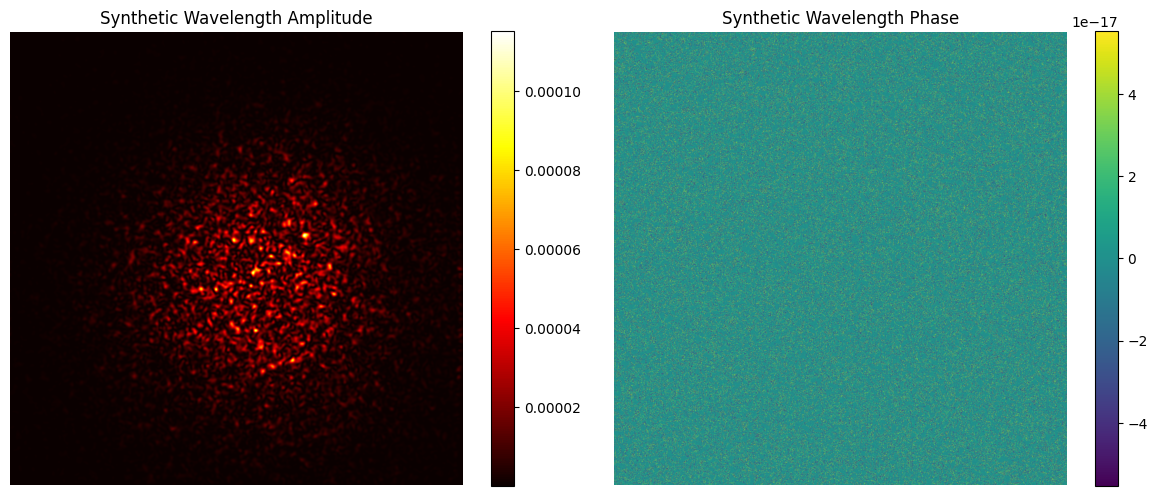

In [51]:
# Calculate synthetic field
synthetic_field = hologram1 * np.conjugate(hologram2)

# Wavelengths in mm (converted from nm)
lambda_1 = 854.315556e-6  # mm
lambda_2 = 854.826164e-6  # mm
synthetic_wavelength = (lambda_1 * lambda_2) / abs(lambda_2 - lambda_1)  # in mm
print(f"Synthetic wavelength: {synthetic_wavelength * 1e6} nm")  # Convert to nm for display

# Calculate amplitude (magnitude of the complex field)
amp1 = np.abs(synthetic_field)

# Calculate phase (in radians)
phase1 = np.angle(synthetic_field)

# Create figure for plotting side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns, adjusted height

# Plot Amplitude
im1 = axs[0].imshow(amp1, cmap='hot')
axs[0].set_title('Synthetic Wavelength Amplitude')
axs[0].axis('off')
plt.colorbar(im1, ax=axs[0])

# Plot Phase
im2 = axs[1].imshow(phase1, cmap='viridis')
axs[1].set_title('Synthetic Wavelength Phase')
axs[1].axis('off')
plt.colorbar(im2, ax=axs[1])

# Adjust layout and display
plt.tight_layout()
plt.show()

# Question 4

/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_71655/574010347.py:48: RuntimeWarning: invalid value encountered in sqrt
  propagation_function = np.exp(1j*2*np.pi*(propagation_distance)*np.sqrt((wave_number**2 - KX**2 - KY**2)))


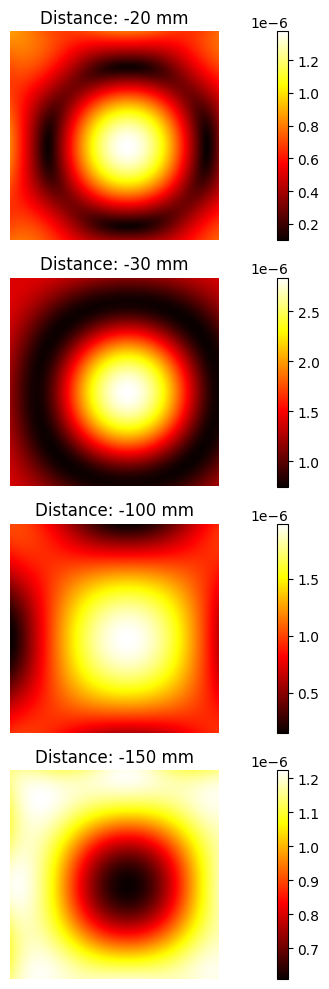

In [ ]:
# Reconstruct and plot
distances = [-20,-30,-100,-150]
fig, axs = plt.subplots(len(distances), 1, figsize=(12, 10))
axs = axs.ravel()

for i, dist in enumerate(distances):
    # Back-propagate the hologram
    reconstructed_field = ASM(synthetic_field, synthetic_wavelength, 0.01, 0.01, dist)
    
    # Calculate intensity (amplitude squared)
    intensity = np.abs(reconstructed_field)
    
    # Plot the intensity
    axs[i].imshow(intensity, cmap='hot')
    axs[i].set_title(f'Distance: {dist} mm')
    axs[i].axis('off')
    plt.colorbar(axs[i].imshow(intensity, cmap='hot'), ax=axs[i])

plt.tight_layout()
plt.show()